## Exploratory Data Analysis
Exploratory data analysis involves studing the features and observations in a dataset in many different ways. The analysis includes univariate, bivariate, and multivariate visualisations covering both numerical and categorical variables. These methods help reveal trends in customer behaviour, restaurant performance, order dynamics, delivery timelines, and operational characteristics. Moreover, EDA also helps in identifying further data inconsistency issues that may have been missed during preprocessing, and as such, EDA and preprocessing go hand-in-hand in building a reliable and error-free dataset for the larger data or machine learning pipeline.

### Importing Libraries and Loading the Data
We load the processed clean dataset and import the libraries required for univariate and bivariate analysis.

In [1]:
import pandas as pd  # Core library for data manipulation and preprocessing
import numpy as np  # Numerical computing library used for arrays and mathematical operations
import matplotlib.pyplot as plt  # Plotting library for generating static visualisations
import seaborn as sns  # Statistical visualisation library built on top of matplotlib

In [2]:
df = pd.read_csv('clean_food_delivery_dataset_interim.csv')  # Load the cleaned food delivery dataset into a pandas DataFrame

### Univariate Analysis
Univariate analysis helps in understanding the distribution of individual variables before exploring relationships between them.

#### Analysing Categorical Variables
We can obtain frequency distributions for categorical features such as city, payment method, order status, and so on.

In [3]:
cat_cols = ['customer_city', 'restaurant_name', 'food_item', 'payment_method', 'order_status']  # Categorical columns

In [4]:
# Frequency distributions of categorical features
for col in cat_cols:
    print('Feature:', col)
    print(df[col].value_counts())
    print()

Feature: customer_city
customer_city
Mumbai       82
New Delhi    64
Pune         48
Nagpur       46
Hyderabad    45
Bengaluru    33
Name: count, dtype: int64

Feature: restaurant_name
restaurant_name
Pizza Hub          102
Foodie Corner       78
The Spice Route     67
Tasty Treats        58
Biryani House       45
Name: count, dtype: int64

Feature: food_item
food_item
Momos       57
Burger      47
Pizza       44
Noodles     44
Coke        42
Biryani     41
Sandwich    38
Pasta       37
Name: count, dtype: int64

Feature: payment_method
payment_method
Cash      104
UPI       102
Card       72
wallet     72
Name: count, dtype: int64

Feature: order_status
order_status
Cancelled    146
Completed    135
Returned      69
Name: count, dtype: int64



#### Analyse Unordered Categorical Variables
We can visualise frequency distributions for categorical features where the categories have no inherent order, such as restaurant names, customer cities, payment methods, and food items.

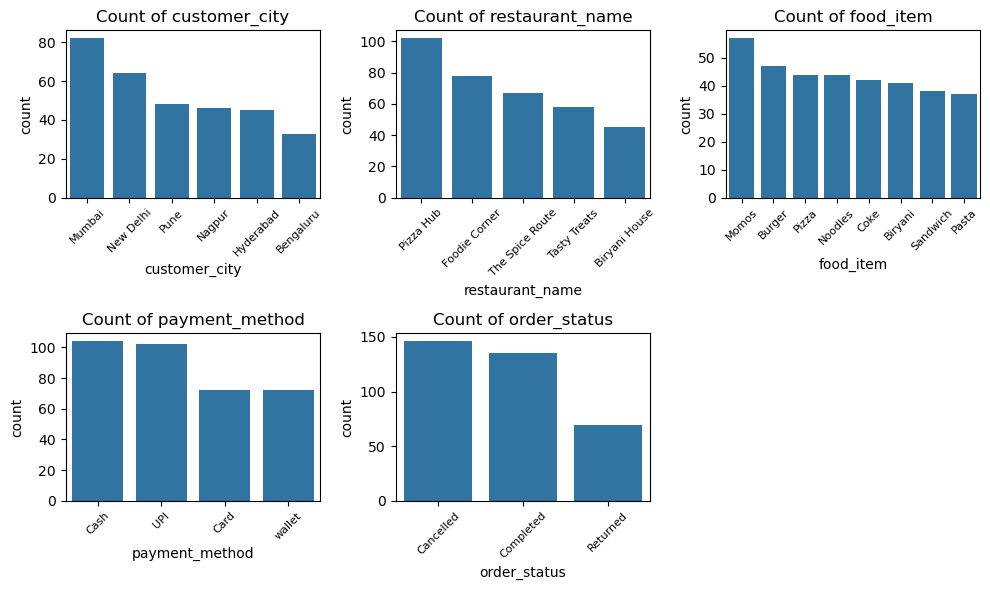

In [5]:
# Visualise frequencies of categorical levels using count plots
plt.figure(figsize = (10, 6))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(x = col, data = df, order = df[col].value_counts().index)
    plt.title(f'Count of {col}')
    plt.xticks(rotation = 45, fontsize = 8)
    if i == 5:
        break

plt.tight_layout()
plt.show()

Countplots are particularly useful in understanding the distribution of categorical features in the data. Frequency counts can indicate imbalance in data, which not only provide useful insights in analysis, but also have implications for downstream activities such as model training.

#### Analysing Ordered Categorical Variables
We can examine categorical features that follow a natural ranking or scale, such as delivery ratings, where the order of values carries meaningful information.

In [6]:
df['delivery_rating'].value_counts()  # Frequency distribution

delivery_rating
3.0    98
6.0    47
2.0    46
4.0    45
0.0    40
5.0    39
1.0    35
Name: count, dtype: int64

The invalid values here point to data entry or data quality issues that need correction.

In [7]:
df['delivery_rating'] = df['delivery_rating'].replace({6: 5})  # Capping delivery rating

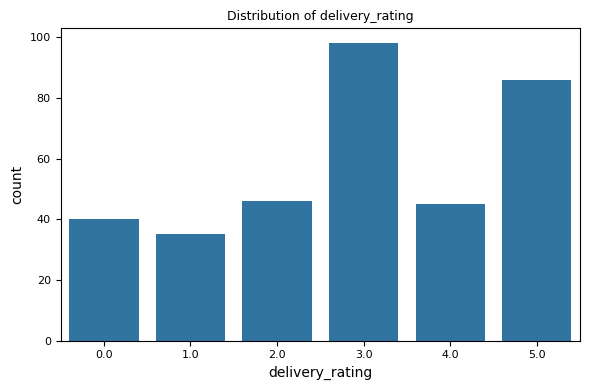

In [8]:
# Count plot of delivery rating
plt.figure(figsize = (6, 4))
sns.countplot(x = 'delivery_rating', data = df, order = sorted(df['delivery_rating'].unique()))
plt.title('Distribution of delivery_rating', fontsize = 9)
plt.xticks(fontsize = 8)
plt.yticks(fontsize = 8)
plt.tight_layout()
plt.show()

We can see that delivery satisfaction appears mostly average, with a noticeable number of low ratings and high ratings.

#### Analysing Numerical Variables
We can understand the distribution, spread, and shape of numerical variables.

In [9]:
num_cols = ['quantity', 'price', 'delivery_time_minutes', 'discount']  # Numerical features

In [10]:
# Summary statistics
for col in num_cols:
    print(df[col].describe())
    print()

count    350.000000
mean       2.148571
std        0.686076
min        1.000000
25%        2.000000
50%        2.000000
75%        3.000000
max        3.000000
Name: quantity, dtype: float64

count    350.000000
mean     224.642343
std       69.830121
min      105.950000
25%      200.000000
50%      200.000000
75%      200.000000
max      496.670000
Name: price, dtype: float64

count    350.000000
mean      20.985714
std       25.588597
min       -5.000000
25%       -5.000000
50%       15.000000
75%       32.750000
max       89.000000
Name: delivery_time_minutes, dtype: float64

count    350.000000
mean       7.800000
std        3.899159
min        5.000000
25%        5.000000
50%        5.000000
75%       10.000000
max       15.000000
Name: discount, dtype: float64



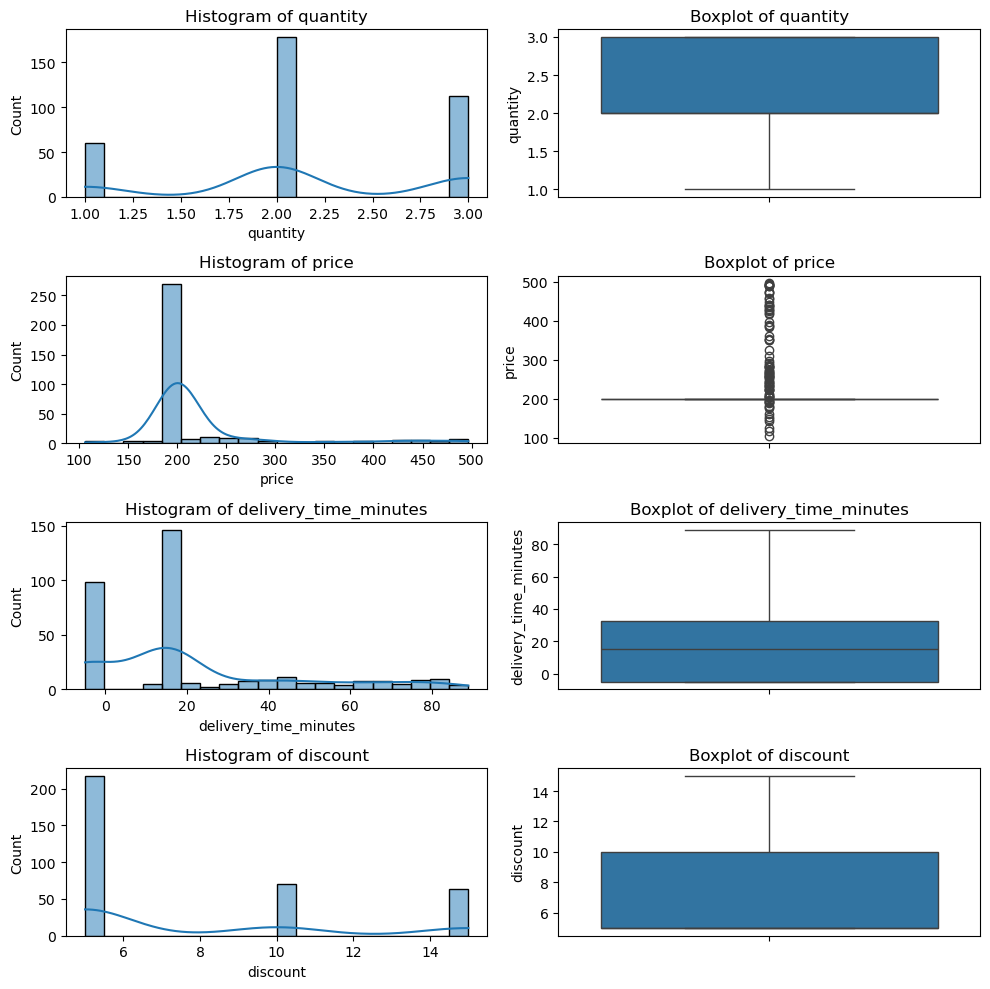

In [11]:
# Visualising distributions
plt.figure(figsize = (10, 10))
k = 0
for col in num_cols:
    k += 1
    plt.subplot(4, 2, k)
    sns.histplot(df[col], bins = 20, kde = True)
    plt.title('Histogram of {}'.format(col))
    k += 1
    plt.subplot(4, 2, k)
    sns.boxplot(df[col])
    plt.title('Boxplot of {}'.format(col))
    
plt.tight_layout()
plt.show()

Histograms and boxplots are used to understand the distribution of numerical features. We can see from these distributions how wide, narrow, or skewed the distributions are for various features. For instance, there is a spike in the price feature indicating that most of the prices fall around that value, but also there are sufficient price points outside that range. In another example, we can see that the histogram of the discount feature indicates that it is probably better to treat discount as an ordinal value, and not a numerical one. We can also see that there is some error in the delivery time, which is showing negative values. This can be rectified.

In [12]:
df['delivery_time_minutes'] = df['delivery_time_minutes'].abs()  # Coercing negative values to non-negative values

#### Segmented Univariate Analysis
We can also analyse how a numerical variable behaves across different subgroups (such as cities or restaurants) to uncover patterns that are not visible in overall summaries.

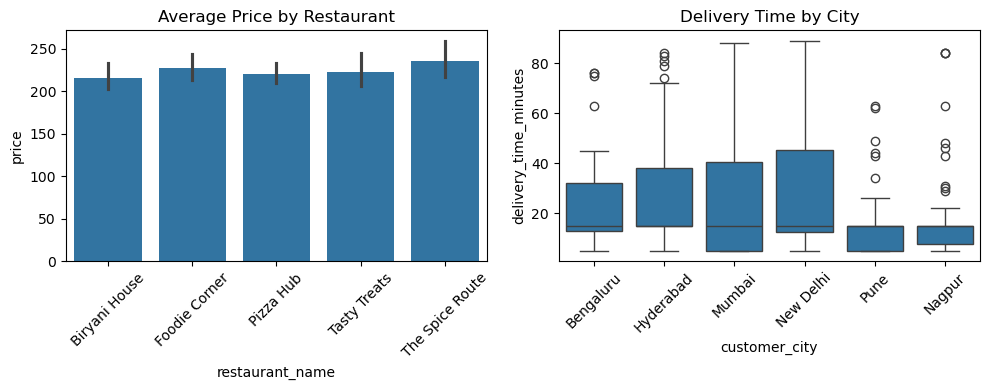

In [13]:
# Segmented univariate analysis
plt.figure(figsize = (10, 4))

# Average price by restaurant
plt.subplot(1, 2, 1)
sns.barplot(x = 'restaurant_name', y = 'price', data = df, estimator = np.mean)
plt.title('Average Price by Restaurant')
plt.xticks(rotation = 45)

# Delivery time by city
plt.subplot(1, 2, 2)
sns.boxplot(x = 'customer_city', y = 'delivery_time_minutes', data = df)
plt.title('Delivery Time by City')
plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

Segmented univariate analysis helps in understanding the behaviour of individual features acress segments. For example, we can see that the variability in delivery time in Mumbai is much greater than that of Nagpur.

### Bivariate Analysis
Bivariate analysis helps identify relationships between pairs of variables. This includes numerical-numerical, numerical-categorical, and categorical-categorical analyses.

#### Numerical vs Numerical
We can check for linear or non-linear relationships between numeric features.

In [14]:
df[num_cols].corr()  # Correlation matrix

,quantity,price,delivery_time_minutes,discount
quantity,1.000000,0.026875,0.039609,-0.011354
price,0.026875,1.000000,-0.054036,0.021709
delivery_time_minutes,0.039609,-0.054036,1.000000,-0.072683
discount,-0.011354,0.021709,-0.072683,1.000000


It appears as though there isn't much correlation between the numerical features in the dataset. This could be good or bad depending on the context. For a machine learning pipelines, this means that there are more predictors to work with. But if we expect some features to be correlated, but they are not, then that needs to be investigated further.

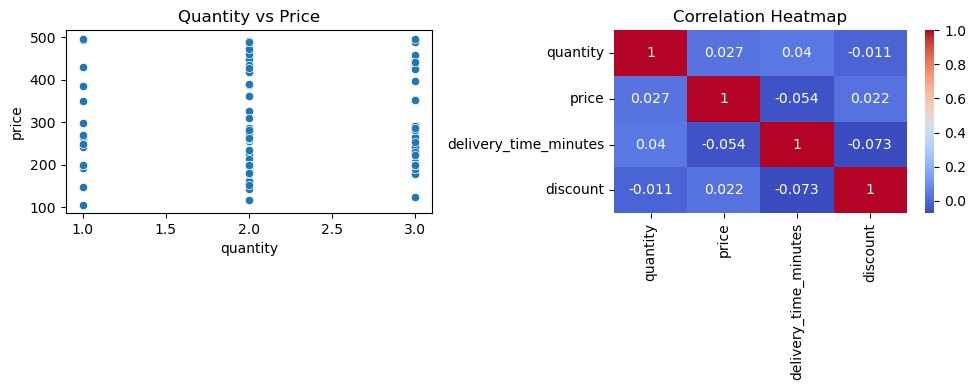

In [15]:
# Scatter plots and correlation heat maps
plt.figure(figsize = (10, 4))

# Scatter plot between quantity and price
plt.subplot(1, 2, 1)
sns.scatterplot(x = 'quantity', y = 'price', data = df)
plt.title('Quantity vs Price')

# Correlation heatmap
plt.subplot(1, 2, 2)
sns.heatmap(df[num_cols].corr(), annot = True, cmap = 'coolwarm')
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

Again, it looks like quantity is better treated as an ordinal feature rather than a numerical feature. Also, the correlation heatmap shows very minimal correlation in the features.

#### Categorical vs Categorical
We can visualise relationships between two categorical variables using frequency tables.

In [16]:
# Pivot table for restaurant vs payment method
pivot = pd.crosstab(df['restaurant_name'], df['payment_method'])
print(pivot)

payment_method   Card  Cash  UPI  wallet
restaurant_name                         
Biryani House      11    12    8      14
Foodie Corner      10    24   29      15
Pizza Hub          25    27   29      21
Tasty Treats       12    20   15      11
The Spice Route    14    21   21      11


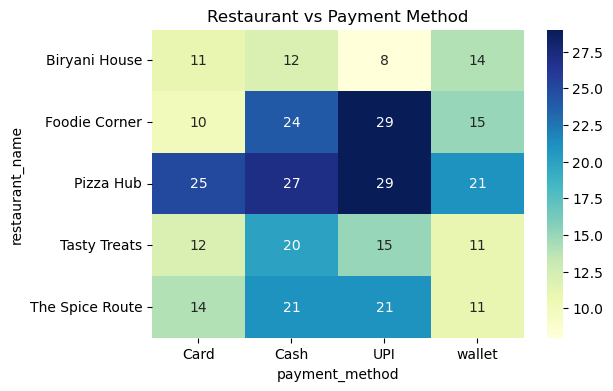

In [17]:
# Heatmap for the same
plt.figure(figsize = (6, 4))
sns.heatmap(pivot, annot = True, fmt = 'd', cmap = 'YlGnBu')
plt.title('Restaurant vs Payment Method')
plt.show()

Frequency tables such as these can show how the preference of payment methods varies across restaurants. For instance, UPI is preferred more in some restaurants and less in others.

#### Numerical vs Categorical
We can compare numerical distributions across categories. This is similar to segmented univariate analysis.

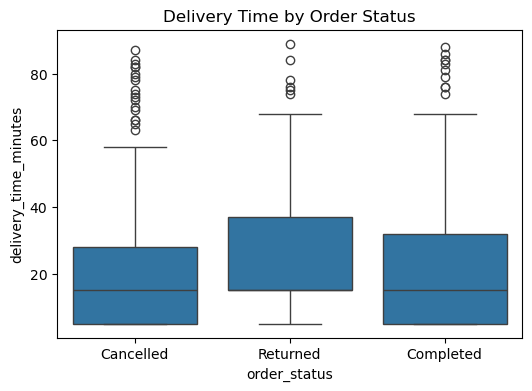

In [18]:
# Delivery time by order status
plt.figure(figsize = (6, 4))
sns.boxplot(x = 'order_status', y = 'delivery_time_minutes', data = df)
plt.title('Delivery Time by Order Status')
plt.show()

We can see how delivery times vary across statuses. For instance, it is expected that most of the cancelled orders are cancelled early, and that most of the returned orders are returned after 20 minutes, which makes sense because the order needs to reach the customer first. Something interesting is that a good number of orders are canelled even after 30 minutes. This indicates a possibility of consistent delayed delivery in some cases, which can be investigated further.

#### Segmented Bivariate Analysis
Insights from bivariate analysis can further be strengthed by segmenting the analysis across groups.

#### Numerical vs Numerical vs Categorical
We can observe behaviour of numerical relationships within subgroups.

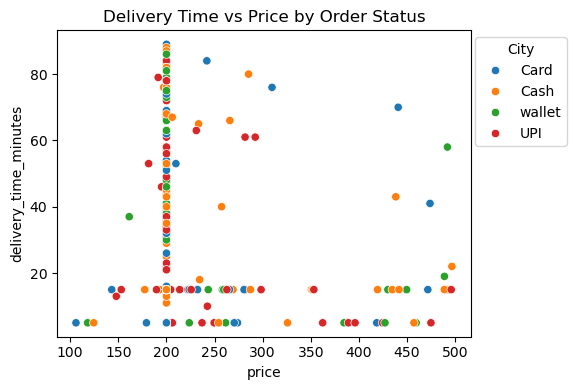

In [19]:
# Scatter plot of quantity vs price segmented by city
plt.figure(figsize = (6, 4))
sns.scatterplot(x = 'price', y = 'delivery_time_minutes', hue = 'payment_method', data = df, palette = 'tab10')
plt.title('Delivery Time vs Price by Order Status')
plt.legend(bbox_to_anchor = (1.25, 1), title = 'City')
plt.tight_layout()
plt.show()

It appears that certain popular products of standard prices (such as around the 200 mark) show a very high variability in the delivery time. It also looks like there are some deliveries that seem to delivery products of varying prices in almost the same time.

#### Numerical vs Categorical vs Categorical
We can observe behaviour of categorical relationships across a numerical range.

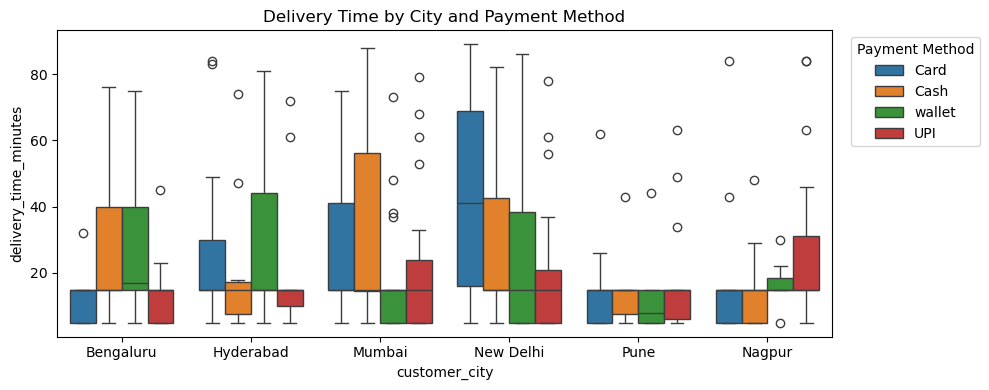

In [20]:
# Delivery time by city and payment method
plt.figure(figsize = (10, 4))
sns.boxplot(x = 'customer_city', y = 'delivery_time_minutes', hue = 'payment_method', data = df, palette = 'tab10')
plt.title('Delivery Time by City and Payment Method')
plt.legend(bbox_to_anchor = (1.2, 1), title = 'Payment Method')
plt.tight_layout()
plt.show()

Segmented bivariate plots such as these help us understand the data in greater depth. For example, it looks like orders paid through UPI show longer delivery time values, whereas in Bengaluru, orders paid through UPI show lower delivery time. This could indicate that the order fulfilment logistics pipeline of some restaurants in some cities need to be looked at. In fact, one could take some hints from Pune, where it seems like the delivery time is universally good for all the payment methods. Whether these are logistics issues or technical issues is for the business owners to understand and act on.

### Pairplots
We can also explore relationships between multiple variables together. It should be noted that pairplots can be memory-intensive to compute and plot.

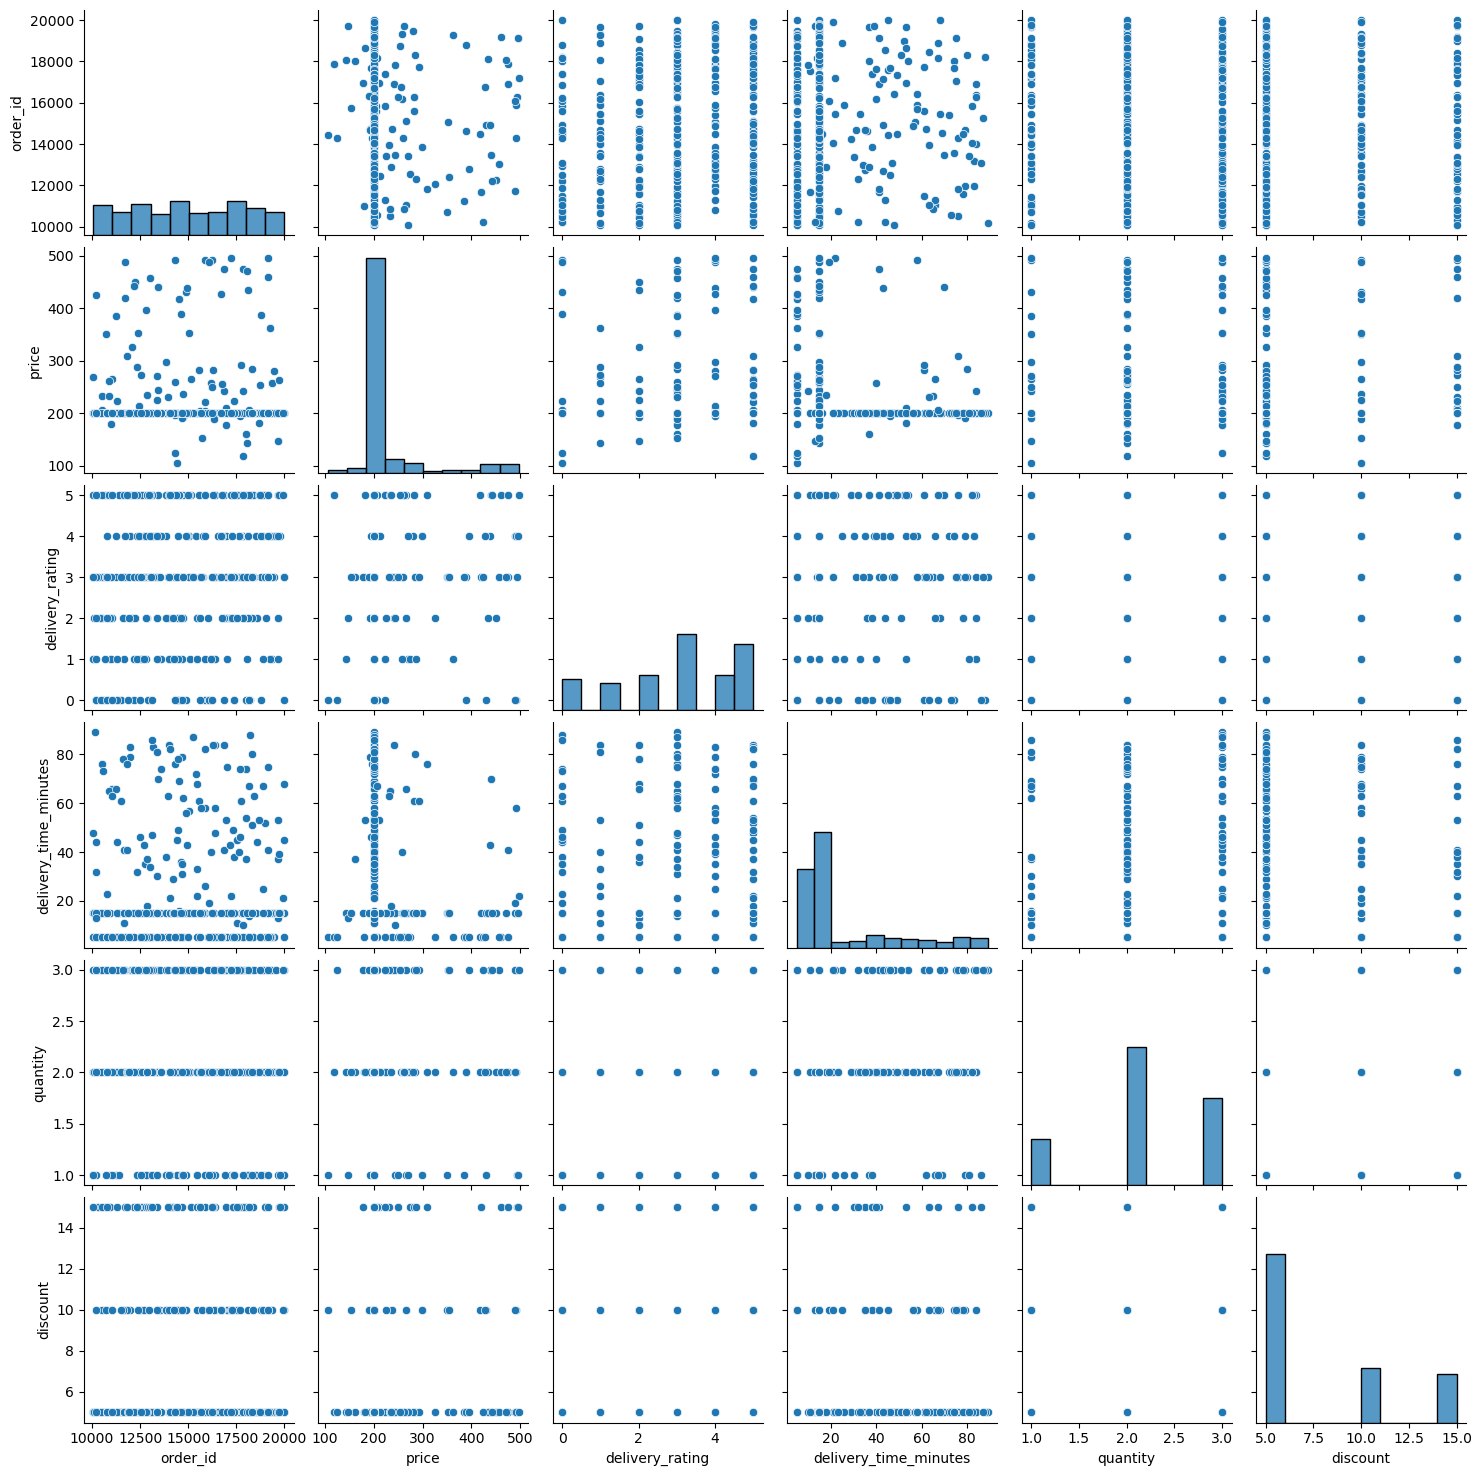

In [21]:
# Pairplot of all numerical features
sns.pairplot(df)
plt.show()

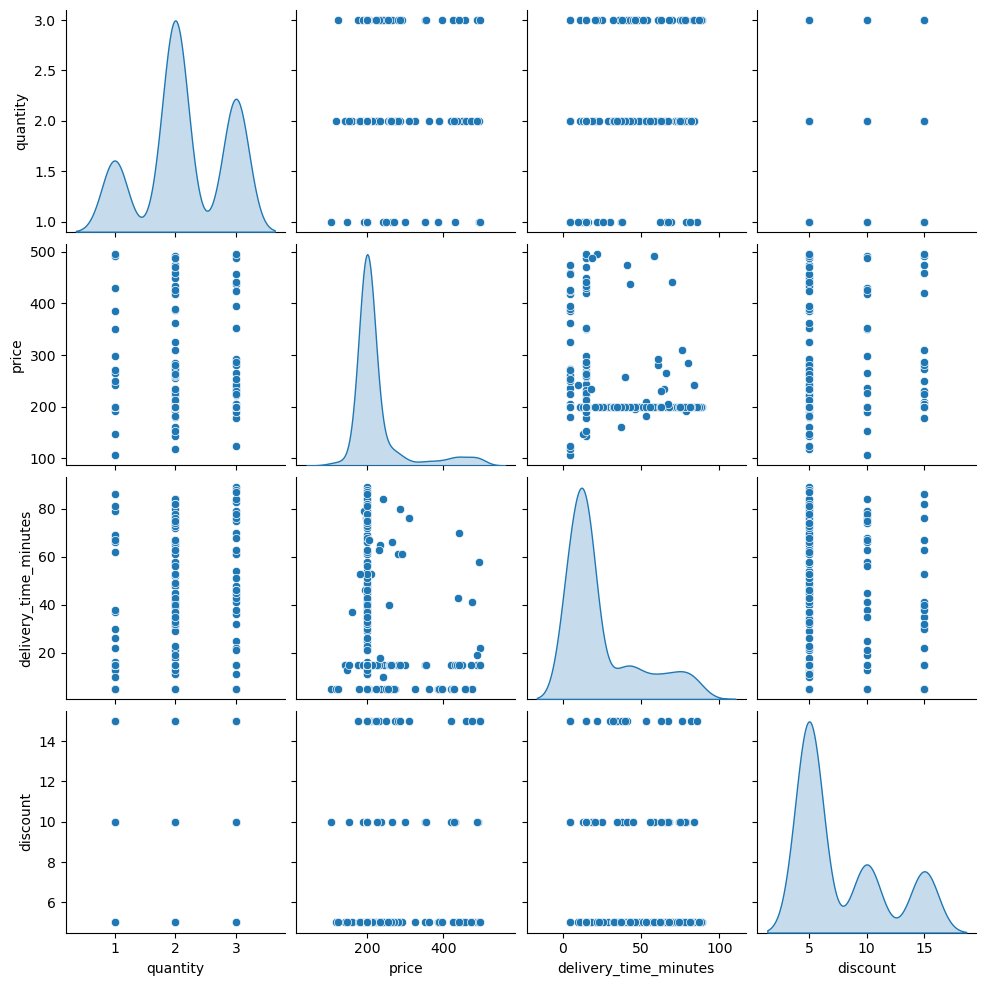

In [22]:
# Pairplot of selected numerical features
sns.pairplot(df[num_cols], diag_kind = 'kde')
plt.show()

### Exporting the Cleaned Dataset
Save the processed dataset in CSV, Excel, or other formats for downstream use.

In [23]:
df.to_csv('clean_food_delivery_dataset.csv', index = False)  # CSV